# Chapter 92 - Final Project: Simple English Generator

The name generator in Chapter 91 modeled short character sequences.

This project applies the same next-character objective to English prose and studies checkpointing, sampling, memorization, and the gap between local plausibility and long-range coherence.

## Learning goals

By the end of this chapter, you will be able to:

- prepare a paragraph-level train-validation split from a small historical corpus;
- train a character-level TinyGPT under CPU constraints;
- track training and held-out cross-entropy loss;
- save and safely reload checkpoints during training;
- select a checkpoint by validation loss;
- compare checkpoints with controlled generation settings;
- compare several sampling temperatures; and
- identify copying, local plausibility, and weak long-range coherence.

## Set expectations

A **corpus** is the text collection used to fit a language model.

A **checkpoint** is a saved snapshot of model and training state at a particular step.

**Local plausibility** means that nearby characters, words, or short phrases resemble English.

**Long-range coherence** means that meaning, topic, participants, and events remain consistent across longer spans.

This model can learn spelling and short phrases, but its tiny data, 64-character context, and small parameter count make coherent paragraphs unlikely.

## Use an attributed historical fixture

The seven short paragraphs below come from the opening of Lewis Carroll's *Alice's Adventures in Wonderland*, published in 1865.

The work is public domain in the United States, but redistribution rules can vary by jurisdiction and edition.

Embedding the fixture avoids network access and keeps every execution reproducible.

In [1]:
source_paragraphs = [
    """Alice was beginning to get very tired of sitting by her sister on the bank,
    and of having nothing to do. Once or twice she had peeped into the book her
    sister was reading, but it had no pictures or conversations in it, and what is
    the use of a book, thought Alice, without pictures or conversation?""",
    """So she was considering in her own mind, as well as she could, for the hot day
    made her feel very sleepy and stupid, whether the pleasure of making a daisy
    chain would be worth the trouble of getting up and picking the daisies, when
    suddenly a white rabbit with pink eyes ran close by her.""",
    """There was nothing so very remarkable in that; nor did Alice think it so very
    much out of the way to hear the rabbit say to itself, Oh dear! Oh dear! I shall
    be too late! But when the rabbit actually took a watch out of its waistcoat
    pocket, and looked at it, and then hurried on, Alice started to her feet.""",
    """The rabbit-hole went straight on like a tunnel for some way, and then dipped
    suddenly down, so suddenly that Alice had not a moment to think about stopping
    herself before she found herself falling down what seemed to be a very deep
    well.""",
    """Either the well was very deep, or she fell very slowly, for she had plenty of
    time as she went down to look about her and to wonder what was going to happen
    next. First, she tried to look down and make out what she was coming to, but it
    was too dark to see anything.""",
    """Down, down, down. Would the fall never come to an end? I wonder how many miles
    I have fallen by this time, she said aloud. I must be getting somewhere near
    the centre of the earth. Let me see: that would be four thousand miles down,
    I think.""",
    """Presently she began again. I wonder if I shall fall right through the earth.
    How funny it will seem to come out among the people that walk with their heads
    downward! The antipathies, I think. She was rather glad there was no one
    listening, this time, as it did not sound at all the right word.""",
]


def normalize_paragraph(paragraph: str) -> str:
    return " ".join(paragraph.split()).lower()


normalized_paragraphs = [
    normalize_paragraph(paragraph) for paragraph in source_paragraphs
]

## Hold out complete paragraphs before repetition

Splitting after repetition would leak the same prose into both sets and make validation loss misleadingly optimistic.

We shuffle paragraph indexes deterministically, reserve two complete paragraphs, and repeat only the five training paragraphs to create more CPU-friendly update opportunities.

In [2]:
import random  # noqa: I001


paragraph_indexes = list(range(len(normalized_paragraphs)))
split_random = random.Random(92)
split_random.shuffle(paragraph_indexes)
validation_indexes = set(paragraph_indexes[:2])
training_paragraphs = [
    paragraph
    for index, paragraph in enumerate(normalized_paragraphs)
    if index not in validation_indexes
]
validation_paragraphs = [
    paragraph
    for index, paragraph in enumerate(normalized_paragraphs)
    if index in validation_indexes
]
training_source_text = "\n\n".join(training_paragraphs)
validation_text = "\n\n".join(validation_paragraphs)
training_text = (training_source_text + "\n\n") * 10

print("training paragraphs:", len(training_paragraphs))
print("held-out paragraphs:", len(validation_paragraphs))
print("training characters after repetition:", len(training_text))
print("held-out characters:", len(validation_text))
print("held-out paragraph openings:")
for paragraph in validation_paragraphs:
    print("-", paragraph[:80] + "...")

training paragraphs: 5
held-out paragraphs: 2
training characters after repetition: 13530
held-out characters: 588
held-out paragraph openings:
- alice was beginning to get very tired of sitting by her sister on the bank, and ...
- so she was considering in her own mind, as well as she could, for the hot day ma...


This is still an unusually small and repetitive corpus, so the validation set is noisy and memorization remains likely.

The split is nevertheless stricter than validating on another copy of training prose.

## Build a fixed character tokenizer

The tokenizer uses a predefined lowercase English alphabet plus punctuation found in the fixture.

Because the inventory is fixed without counting held-out sequences, token coverage does not reveal validation word or phrase statistics.

In [3]:
characters = sorted(set("\n abcdefghijklmnopqrstuvwxyz,.!?;:'-"))
character_to_id = {character: token_id for token_id, character in enumerate(characters)}
id_to_character = {
    token_id: character for character, token_id in character_to_id.items()
}


def encode_text(text: str) -> list[int]:
    unknown_characters = sorted(set(text) - set(character_to_id))
    if unknown_characters:
        raise ValueError(f"Unknown characters: {unknown_characters}")
    return [character_to_id[character] for character in text]


def decode_token_ids(token_ids: list[int]) -> str:
    return "".join(id_to_character[token_id] for token_id in token_ids)


round_trip_text = "alice was beginning."
assert decode_token_ids(encode_text(round_trip_text)) == round_trip_text
print("vocabulary size:", len(characters))
print("tokens:", [repr(character) for character in characters])

vocabulary size: 36
tokens: ["'\\n'", "' '", "'!'", '"\'"', "','", "'-'", "'.'", "':'", "';'", "'?'", "'a'", "'b'", "'c'", "'d'", "'e'", "'f'", "'g'", "'h'", "'i'", "'j'", "'k'", "'l'", "'m'", "'n'", "'o'", "'p'", "'q'", "'r'", "'s'", "'t'", "'u'", "'v'", "'w'", "'x'", "'y'", "'z'"]


## Create shifted training batches

Every target is the character immediately after the corresponding input character.

An explicit PyTorch generator makes sampled batch positions reproducible without coupling them to generation or evaluation randomness.

In [4]:
import torch  # noqa: I001


training_token_ids = torch.tensor(encode_text(training_text), dtype=torch.long)
validation_token_ids = torch.tensor(encode_text(validation_text), dtype=torch.long)


def get_training_batch(
    token_ids: torch.Tensor,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    if token_ids.ndim != 1:
        raise ValueError("token_ids must be one-dimensional.")
    number_of_starts = token_ids.shape[0] - context_length
    if number_of_starts < 1:
        raise ValueError("The token stream is too short for this context length.")
    start_indexes = torch.randint(
        0, number_of_starts, (batch_size,), generator=generator
    )
    inputs = torch.stack(
        [token_ids[start : start + context_length] for start in start_indexes]
    )
    targets = torch.stack(
        [token_ids[start + 1 : start + context_length + 1] for start in start_indexes]
    )
    return inputs, targets


test_generator = torch.Generator().manual_seed(92)
test_inputs, test_targets = get_training_batch(
    training_token_ids, batch_size=4, context_length=16, generator=test_generator
)
print("input shape:", tuple(test_inputs.shape))
print("target shift is correct:", torch.equal(test_inputs[:, 1:], test_targets[:, :-1]))

input shape: (4, 16)
target shift is correct: True


## Define the character-level TinyGPT

The vectorized causal-attention implementation matches the architecture used in the preceding projects.

Its generation method accepts an explicit random generator so checkpoint and temperature comparisons can reuse controlled sampling streams.

In [5]:
import math  # noqa: I001
import torch


class MultiHeadCausalSelfAttention(torch.nn.Module):
    embedding_dimension: int
    number_of_attention_heads: int
    head_size: int

    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        if embedding_dimension % number_of_attention_heads != 0:
            raise ValueError("Attention heads must divide the embedding dimension.")
        self.embedding_dimension = embedding_dimension
        self.number_of_attention_heads = number_of_attention_heads
        self.head_size = embedding_dimension // number_of_attention_heads
        self.query_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.key_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.value_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension, bias=False
        )
        self.output_projection = torch.nn.Linear(
            embedding_dimension, embedding_dimension
        )
        self.attention_dropout = torch.nn.Dropout(dropout_rate)
        self.output_dropout = torch.nn.Dropout(dropout_rate)
        self.register_buffer(
            "causal_mask",
            torch.tril(torch.ones(context_length, context_length, dtype=torch.bool)),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        batch_size, sequence_length, _ = input_values.shape

        def split_heads(values: torch.Tensor) -> torch.Tensor:
            return values.view(
                batch_size,
                sequence_length,
                self.number_of_attention_heads,
                self.head_size,
            ).transpose(1, 2)

        queries = split_heads(self.query_projection(input_values))
        keys = split_heads(self.key_projection(input_values))
        values = split_heads(self.value_projection(input_values))
        attention_scores = queries @ keys.transpose(-2, -1)
        attention_scores = attention_scores / math.sqrt(self.head_size)
        causal_mask = self.causal_mask[:sequence_length, :sequence_length]
        attention_scores = attention_scores.masked_fill(~causal_mask, float("-inf"))
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attended_values = self.attention_dropout(attention_weights) @ values
        concatenated_values = (
            attended_values.transpose(1, 2)
            .contiguous()
            .view(batch_size, sequence_length, self.embedding_dimension)
        )
        projected_values = self.output_projection(concatenated_values)
        output_values: torch.Tensor = self.output_dropout(projected_values)
        return output_values

In [6]:
class FeedForwardNetwork(torch.nn.Module):
    def __init__(self, embedding_dimension: int, dropout_rate: float) -> None:
        super().__init__()
        self.network = torch.nn.Sequential(
            torch.nn.Linear(embedding_dimension, 4 * embedding_dimension),
            torch.nn.ReLU(),
            torch.nn.Linear(4 * embedding_dimension, embedding_dimension),
            torch.nn.Dropout(dropout_rate),
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        output_values: torch.Tensor = self.network(input_values)
        return output_values


class TransformerBlock(torch.nn.Module):
    def __init__(
        self,
        embedding_dimension: int,
        number_of_attention_heads: int,
        context_length: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.attention_norm = torch.nn.LayerNorm(embedding_dimension)
        self.attention = MultiHeadCausalSelfAttention(
            embedding_dimension=embedding_dimension,
            number_of_attention_heads=number_of_attention_heads,
            context_length=context_length,
            dropout_rate=dropout_rate,
        )
        self.feedforward_norm = torch.nn.LayerNorm(embedding_dimension)
        self.feedforward = FeedForwardNetwork(
            embedding_dimension=embedding_dimension,
            dropout_rate=dropout_rate,
        )

    def forward(self, input_values: torch.Tensor) -> torch.Tensor:
        attention_branch = self.attention(self.attention_norm(input_values))
        values_after_attention = input_values + attention_branch
        feedforward_branch = self.feedforward(
            self.feedforward_norm(values_after_attention)
        )
        output_values: torch.Tensor = values_after_attention + feedforward_branch
        return output_values


class TinyGPT(torch.nn.Module):
    vocabulary_size: int
    context_length: int

    def __init__(
        self,
        vocabulary_size: int,
        context_length: int,
        embedding_dimension: int,
        number_of_attention_heads: int,
        number_of_transformer_blocks: int,
        dropout_rate: float,
    ) -> None:
        super().__init__()
        self.vocabulary_size = vocabulary_size
        self.context_length = context_length
        self.token_embedding = torch.nn.Embedding(vocabulary_size, embedding_dimension)
        self.position_embedding = torch.nn.Embedding(
            context_length, embedding_dimension
        )
        self.embedding_dropout = torch.nn.Dropout(dropout_rate)
        self.transformer_blocks = torch.nn.Sequential(
            *[
                TransformerBlock(
                    embedding_dimension=embedding_dimension,
                    number_of_attention_heads=number_of_attention_heads,
                    context_length=context_length,
                    dropout_rate=dropout_rate,
                )
                for _ in range(number_of_transformer_blocks)
            ]
        )
        self.final_norm = torch.nn.LayerNorm(embedding_dimension)
        self.output_layer = torch.nn.Linear(embedding_dimension, vocabulary_size)

    def forward(
        self,
        input_token_ids: torch.Tensor,
        target_token_ids: torch.Tensor | None = None,
    ) -> tuple[torch.Tensor, torch.Tensor | None]:
        if input_token_ids.ndim != 2:
            raise ValueError("Inputs must have shape [batch, time].")
        batch_size, sequence_length = input_token_ids.shape
        if sequence_length > self.context_length:
            raise ValueError("Input exceeds model context length.")
        position_ids = torch.arange(sequence_length, device=input_token_ids.device)
        hidden_values = self.token_embedding(input_token_ids)
        hidden_values = hidden_values + self.position_embedding(position_ids)
        hidden_values = self.embedding_dropout(hidden_values)
        hidden_values = self.transformer_blocks(hidden_values)
        logits = self.output_layer(self.final_norm(hidden_values))
        loss = None
        if target_token_ids is not None:
            if target_token_ids.shape != input_token_ids.shape:
                raise ValueError("Targets must have the same shape as inputs.")
            loss = torch.nn.functional.cross_entropy(
                logits.reshape(batch_size * sequence_length, self.vocabulary_size),
                target_token_ids.reshape(batch_size * sequence_length),
            )
        return logits, loss

    @torch.no_grad()
    def generate(
        self,
        input_token_ids: torch.Tensor,
        number_of_new_tokens: int,
        generator: torch.Generator,
        temperature: float = 1.0,
        top_k: int | None = None,
    ) -> torch.Tensor:
        if temperature <= 0:
            raise ValueError("temperature must be positive.")
        generated_ids = input_token_ids
        for _ in range(number_of_new_tokens):
            model_input = generated_ids[:, -self.context_length :]
            logits, _ = self(model_input)
            next_logits = logits[:, -1] / temperature
            if top_k is not None:
                effective_top_k = min(top_k, self.vocabulary_size)
                top_values, _ = torch.topk(next_logits, effective_top_k)
                next_logits = next_logits.masked_fill(
                    next_logits < top_values[:, -1, None], float("-inf")
                )
            probabilities = torch.softmax(next_logits, dim=-1)
            next_ids = torch.multinomial(
                probabilities, num_samples=1, generator=generator
            )
            generated_ids = torch.cat([generated_ids, next_ids], dim=1)
        return generated_ids

## Configure the CPU experiment

The 64-character context can cover short phrases but not an entire paragraph.

Four evaluation points keep checkpoint comparison readable while limiting execution time.

In [7]:
from dataclasses import dataclass  # noqa: I001
from pathlib import Path  # noqa: I001
import tempfile  # noqa: I001


@dataclass(frozen=True)
class CheckpointRecord:
    step: int
    path: Path
    training_loss: float
    validation_loss: float


context_length = 64
training_steps = 600
evaluation_interval = 200
model_config: dict[str, int | float | str] = {
    "architecture": "TinyGPT-v1",
    "vocabulary_size": len(characters),
    "context_length": context_length,
    "embedding_dimension": 64,
    "number_of_attention_heads": 4,
    "number_of_transformer_blocks": 2,
    "dropout_rate": 0.1,
}

torch.manual_seed(92)
model = TinyGPT(
    vocabulary_size=len(characters),
    context_length=context_length,
    embedding_dimension=64,
    number_of_attention_heads=4,
    number_of_transformer_blocks=2,
    dropout_rate=0.1,
)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)
training_batch_generator = torch.Generator().manual_seed(9201)
training_evaluation_generator = torch.Generator().manual_seed(9202)
validation_evaluation_generator = torch.Generator().manual_seed(9203)
checkpoint_directory = tempfile.TemporaryDirectory()
checkpoint_root = Path(checkpoint_directory.name)

print("parameters:", sum(parameter.numel() for parameter in model.parameters()))
print("context length:", context_length)
print("training steps:", training_steps)

parameters: 108452
context length: 64
training steps: 600


## Evaluate and save checkpoints

An inference checkpoint needs the model tensors and architecture config, while exact training resumption also needs optimizer state and the completed step.

The files are written under a temporary directory and removed after all loading demonstrations finish.

In [8]:
@torch.no_grad()
def estimate_loss(
    model_to_evaluate: TinyGPT,
    token_ids: torch.Tensor,
    batch_size: int,
    number_of_batches: int,
    generator: torch.Generator,
) -> float:
    was_training = model_to_evaluate.training
    model_to_evaluate.eval()
    losses: list[float] = []
    for _ in range(number_of_batches):
        inputs, targets = get_training_batch(
            token_ids, batch_size, context_length, generator
        )
        _, loss = model_to_evaluate(inputs, targets)
        if loss is None:
            raise RuntimeError("Evaluation loss was not computed.")
        losses.append(loss.item())
    model_to_evaluate.train(was_training)
    return sum(losses) / len(losses)


def save_checkpoint(
    model_to_save: TinyGPT,
    optimizer_to_save: torch.optim.Optimizer,
    step: int,
    training_loss: float,
    validation_loss: float,
) -> Path:
    checkpoint_path = checkpoint_root / f"checkpoint-step-{step}.pt"
    torch.save(
        {
            "format_version": 1,
            "step": step,
            "model_config": model_config,
            "tokenizer_data": {"token_to_id": character_to_id},
            "model_state_dict": model_to_save.state_dict(),
            "optimizer_state_dict": optimizer_to_save.state_dict(),
            "training_loss": training_loss,
            "validation_loss": validation_loss,
        },
        checkpoint_path,
    )
    return checkpoint_path

## Train and checkpoint

Each evaluation uses independent batch randomness, and every saved metric describes the exact model state written at that step.

Gradient clipping limits unusually large update norms before AdamW changes the parameters.

In [9]:
evaluation_steps: list[int] = []
training_losses: list[float] = []
validation_losses: list[float] = []
checkpoint_records: list[CheckpointRecord] = []


def evaluate_and_checkpoint(step: int) -> None:
    training_loss = estimate_loss(
        model,
        training_token_ids,
        batch_size=16,
        number_of_batches=8,
        generator=training_evaluation_generator,
    )
    validation_loss = estimate_loss(
        model,
        validation_token_ids,
        batch_size=16,
        number_of_batches=8,
        generator=validation_evaluation_generator,
    )
    checkpoint_path = save_checkpoint(
        model, optimizer, step, training_loss, validation_loss
    )
    evaluation_steps.append(step)
    training_losses.append(training_loss)
    validation_losses.append(validation_loss)
    checkpoint_records.append(
        CheckpointRecord(step, checkpoint_path, training_loss, validation_loss)
    )
    print(
        f"step {step:>3} | train {training_loss:.3f} "
        f"| validation {validation_loss:.3f} | checkpoint saved"
    )


evaluate_and_checkpoint(0)
model.train()
for step in range(1, training_steps + 1):
    inputs, targets = get_training_batch(
        training_token_ids,
        batch_size=16,
        context_length=context_length,
        generator=training_batch_generator,
    )
    logits, loss = model(inputs, targets)
    if loss is None or not torch.isfinite(loss):
        raise RuntimeError("Training loss is missing or non-finite.")
    if logits.shape[-1] != len(characters):
        raise RuntimeError("The model output does not match the vocabulary.")
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    if step % evaluation_interval == 0:
        evaluate_and_checkpoint(step)

assert len(checkpoint_records) == 4

step   0 | train 3.762 | validation 3.795 | checkpoint saved


step 200 | train 2.233 | validation 2.381 | checkpoint saved


step 400 | train 2.081 | validation 2.371 | checkpoint saved


step 600 | train 1.910 | validation 2.404 | checkpoint saved


The widening gap between training and validation loss indicates that the model increasingly specializes in repeated training paragraphs.

The held-out curve, rather than the final training loss, determines which saved snapshot we select.

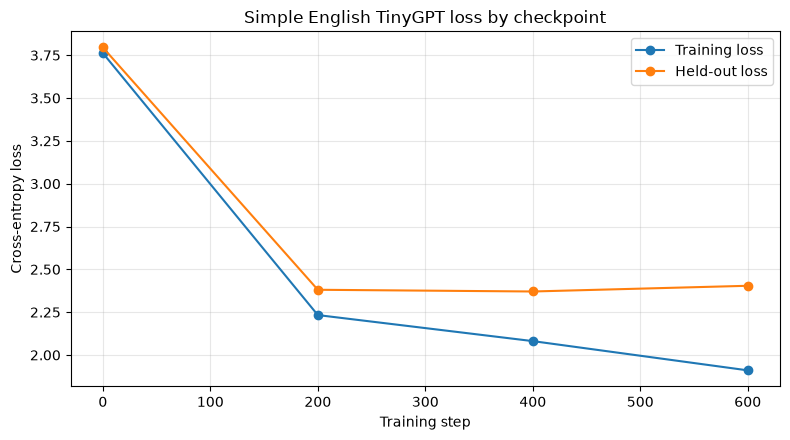

In [10]:
import matplotlib.pyplot as plt  # noqa: I001


plt.figure(figsize=(8, 4.5))
plt.plot(evaluation_steps, training_losses, marker="o", label="Training loss")
plt.plot(evaluation_steps, validation_losses, marker="o", label="Held-out loss")
plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Simple English TinyGPT loss by checkpoint")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Load checkpoint tensors defensively

`weights_only=True` restricts PyTorch loading to tensors and basic container values, but artifacts should still come from trusted sources.

The loader validates the payload and uses strict state-dictionary loading before switching off dropout.

In [11]:
def require_config_int(config: dict[str, object], key: str) -> int:
    value = config.get(key)
    if type(value) is not int or value < 1:
        raise ValueError(f"{key} must be a positive integer.")
    return value


def require_config_float(config: dict[str, object], key: str) -> float:
    value = config.get(key)
    if type(value) is int:
        numeric_value = float(value)
    elif type(value) is float:
        numeric_value = value
    else:
        raise ValueError(f"{key} must be numeric.")
    if not 0.0 <= numeric_value < 1.0:
        raise ValueError(f"{key} must be at least 0 and less than 1.")
    return numeric_value


def build_model_from_config(config: dict[str, object]) -> TinyGPT:
    if config.get("architecture") != "TinyGPT-v1":
        raise ValueError("Unsupported model architecture.")
    return TinyGPT(
        vocabulary_size=require_config_int(config, "vocabulary_size"),
        context_length=require_config_int(config, "context_length"),
        embedding_dimension=require_config_int(config, "embedding_dimension"),
        number_of_attention_heads=require_config_int(
            config, "number_of_attention_heads"
        ),
        number_of_transformer_blocks=require_config_int(
            config, "number_of_transformer_blocks"
        ),
        dropout_rate=require_config_float(config, "dropout_rate"),
    )


def load_checkpoint_model(checkpoint_path: Path) -> tuple[TinyGPT, int]:
    loaded_value: object = torch.load(
        checkpoint_path, map_location="cpu", weights_only=True
    )
    if not isinstance(loaded_value, dict):
        raise TypeError("Checkpoint must contain a dictionary.")
    if loaded_value.get("format_version") != 1:
        raise ValueError("Unsupported checkpoint format version.")
    step = loaded_value.get("step")
    if type(step) is not int:
        raise TypeError("Checkpoint step must be an integer.")
    raw_config = loaded_value.get("model_config")
    if not isinstance(raw_config, dict):
        raise TypeError("Checkpoint model config must be a dictionary.")
    checkpoint_config: dict[str, object] = {}
    for key, value in raw_config.items():
        if not isinstance(key, str):
            raise TypeError("Model config keys must be strings.")
        checkpoint_config[key] = value
    raw_tokenizer_data = loaded_value.get("tokenizer_data")
    if not isinstance(raw_tokenizer_data, dict):
        raise TypeError("Checkpoint tokenizer data must be a dictionary.")
    if raw_tokenizer_data.get("token_to_id") != character_to_id:
        raise ValueError("Checkpoint tokenizer does not match this notebook.")
    raw_state = loaded_value.get("model_state_dict")
    if not isinstance(raw_state, dict):
        raise TypeError("Checkpoint model state must be a dictionary.")
    state_dict: dict[str, torch.Tensor] = {}
    for key, value in raw_state.items():
        if not isinstance(key, str) or not isinstance(value, torch.Tensor):
            raise TypeError("Model state entries must map strings to tensors.")
        state_dict[key] = value
    loaded_model = build_model_from_config(checkpoint_config)
    if loaded_model.vocabulary_size != len(character_to_id):
        raise ValueError("Model and tokenizer vocabulary sizes do not match.")
    loaded_model.load_state_dict(state_dict, strict=True)
    loaded_model.eval()
    return loaded_model, step

## Generate with controlled randomness

The helper preserves the full prompt in its returned text while the model conditions only on the most recent context window.

An explicit seed creates a fresh generator for each comparison.

In [12]:
@torch.no_grad()
def generate_text(
    model_to_sample: TinyGPT,
    prompt: str,
    number_of_new_tokens: int,
    temperature: float,
    top_k: int | None,
    seed: int,
) -> str:
    if not prompt:
        raise ValueError("Prompt must not be empty.")
    prompt_ids = encode_text(prompt)
    model_input_ids = torch.tensor(
        [prompt_ids[-model_to_sample.context_length :]], dtype=torch.long
    )
    generator = torch.Generator().manual_seed(seed)
    model_to_sample.eval()
    generated_ids = model_to_sample.generate(
        model_input_ids,
        number_of_new_tokens=number_of_new_tokens,
        generator=generator,
        temperature=temperature,
        top_k=top_k,
    )
    continuation_ids = generated_ids[0, model_input_ids.shape[1] :].tolist()
    return prompt + decode_token_ids([int(token_id) for token_id in continuation_ids])

## Compare checkpoints fairly

Every checkpoint receives the same prompt, temperature, top-k limit, seed, and output length.

Early text should resemble random characters, while later text should acquire spaces, word fragments, and familiar short phrases.

In [13]:
checkpoint_samples: dict[int, str] = {}
for record in checkpoint_records:
    checkpoint_model, loaded_step = load_checkpoint_model(record.path)
    if loaded_step != record.step:
        raise RuntimeError("Loaded checkpoint step does not match its record.")
    checkpoint_samples[record.step] = generate_text(
        checkpoint_model,
        prompt="alice was",
        number_of_new_tokens=160,
        temperature=0.8,
        top_k=15,
        seed=92,
    )
    print("=" * 72)
    print(
        f"step {record.step} | train {record.training_loss:.3f} "
        f"| validation {record.validation_loss:.3f}"
    )
    print(checkpoint_samples[record.step])

step 0 | train 3.762 | validation 3.795
alice wasdkx uxg!,!eiux
yn.'lpohgo;w;aag!'v'xquf:,k:tpqgc:
eeinfn,v,!g?,kckwagoptwq;ca:gac:tpoww.;,ao-!.f,:.?wf?s?ov?wr?opvuvlw..kp,po
,cavkqr-ovtvv!,!;?oc?
llpwv!o?cvcc


step 200 | train 2.233 | validation 2.381
alice was th art mer d dont lp thowtoman fout d thatthe wat hind thalle tcowato theeratratot out t air!.

e le as fo weer touly ase ton, ritar o thath t t s ll semore as


step 400 | train 2.081 | validation 2.371
alice was th art mer d hent.
p thowtoman fouthery, the hint s d seveng the wato ther ttratot owt wankr!.





theral weer tone, ase the, ritherinthe wha t s ll semor t s


step 600 | train 1.910 | validation 2.404
alice was th rend re de wnthe theng sathe t t do bowaler bbe wn teven butcowato touaratratot out e air!.



thersthe werd thely as athe, rithr! thinde t tcerelisemor t a


The comparison demonstrates learning progress, but a more grammatical excerpt does not prove that the surrounding passage has a consistent topic or narrative.

## Select by held-out loss

Choosing the minimum validation loss is an explicit rule that does not depend on which generated sample looks most appealing.

With only two held-out paragraphs, this selection is illustrative rather than statistically reliable.

In [14]:
best_record = min(checkpoint_records, key=lambda record: record.validation_loss)
best_model, best_step = load_checkpoint_model(best_record.path)
final_record = checkpoint_records[-1]

print("best checkpoint step:", best_step)
print("best validation loss:", round(best_record.validation_loss, 3))
print("final checkpoint step:", final_record.step)
print("final validation loss:", round(final_record.validation_loss, 3))

best checkpoint step: 400
best validation loss: 2.371
final checkpoint step: 600
final validation loss: 2.404


## Compare sampling temperatures

Temperature rescales logits before softmax: values below 1 sharpen the distribution, while values above 1 flatten it.

Using the same seed makes the comparison controlled, although changing probabilities can still cause trajectories to diverge immediately.

In [15]:
temperature_samples: dict[float, str] = {}
for temperature in [0.5, 0.8, 1.0, 1.2]:
    sample = generate_text(
        best_model,
        prompt="alice was",
        number_of_new_tokens=260,
        temperature=temperature,
        top_k=15,
        seed=920,
    )
    temperature_samples[temperature] = sample
    print("=" * 72)
    print("temperature:", temperature)
    print(sample)

temperature: 0.5
alice was t the the out at t wo or wo inllo ay t her t t the s wh wat theak to t ather towound wathee was the t s was wathalitocok at f wat tout ar as her t d to t tout wan oout ther acout s ven, war the wathabe at ll t as t wo t f thelit we t t a t o mo o sas thoouto 


temperature: 0.8
alice was t nd tome ome at thind r wowanllo ay t her t; wnke s wh wat thede tome aithenkavest we wo want o we ase wad waved t s s fat faleer wan iry dohar radderatheng, wher therthemer me t s lip, ar s t wave wale slar! is towowhelithabinto tong s t oth woasand. o at s


temperature: 1.0
alice was t nd tome ome st oung shar a illor thenk o t; wn. wnk. wo t thede tome aithenkavest wn wo w w; o we ase wad wavedin. was faritowar men iry dohar radderthe oud wher oudethay wcer t shin, war that wal w d helar! is ve f t f tchelery tong a t oth woasas thoouto 


temperature: 1.2
alice was t nd tomomome st oung sr wow illf ay t har t; wn. wnk. wo t thede tomik meedokavest wn wh.e whilowe ase wad wavedin.. lkat was war men. ry dohar radderatokoud wwn omourthay wcous vevlf, war t t wave w ve dld whis ve f t f tcheler t ong a t othowoasas thoouco 


Lower temperatures usually favor common continuations and repetition, while higher temperatures admit less likely characters and more malformed words.

The middle settings can produce recognizable local English without maintaining a coherent paragraph.

## Check exact copying

Repeated training paragraphs make verbatim reuse especially important to inspect.

The longest-common-substring calculation finds the longest contiguous character span shared by a generated continuation and the unrepeated training source.

In [16]:
def longest_shared_substring(first_text: str, second_text: str) -> str:
    previous_lengths = [0] * (len(second_text) + 1)
    best_length = 0
    best_end = 0
    for first_index, first_character in enumerate(first_text, start=1):
        current_lengths = [0] * (len(second_text) + 1)
        for second_index, second_character in enumerate(second_text, start=1):
            if first_character == second_character:
                current_lengths[second_index] = previous_lengths[second_index - 1] + 1
                if current_lengths[second_index] > best_length:
                    best_length = current_lengths[second_index]
                    best_end = first_index
        previous_lengths = current_lengths
    return first_text[best_end - best_length : best_end]


copy_check_sample = temperature_samples[0.8]
generated_continuation = copy_check_sample[len("alice was") :]
longest_match = longest_shared_substring(generated_continuation, training_source_text)
print("longest exact training match length:", len(longest_match))
print("longest exact training match:", repr(longest_match))

longest exact training match length: 7
longest exact training match: 'her the'


A long match is a warning sign, but this diagnostic does not distinguish memorized prose from common short phrases by itself.

It also cannot detect paraphrase or other non-exact forms of reuse.

## Review quality consistently

For each sample, ask:

- Are characters, spaces, and punctuation placed plausibly?
- Are there recognizable words and short phrases?
- Does the text repeat a word or fragment excessively?
- Does a sentence preserve a subject or action?
- Does the passage maintain a topic beyond the 64-character context?
- Does it reproduce an unusually long training span?

These questions separate local surface quality from coherence and originality.

## Remove temporary checkpoint artifacts

Real training jobs keep checkpoints in a deliberate artifact directory.

This instructional notebook removes its temporary files only after proving that every checkpoint can be reloaded.

In [17]:
checkpoint_directory.cleanup()
print("temporary checkpoints removed:", not checkpoint_root.exists())

temporary checkpoints removed: True


## Limits of the experiment

- Five repeated training paragraphs cannot represent English broadly.
- Two held-out paragraphs cannot provide a stable estimate of generalization.
- Character tokens require many prediction steps to form words.
- A 64-character context cannot preserve paragraph-scale information.
- Roughly one hundred thousand parameters provide limited capacity.
- Sampling settings can make the same checkpoint appear better or worse.

More parameters without substantially more varied data could increase memorization rather than solve these limits.

## Takeaways

- Hold out complete source units before repeating or chunking text.
- Save checkpoint state and its matching config, then validate and strictly load it.
- Compare checkpoints with identical prompts and sampling settings.
- Select checkpoints by a predefined held-out metric rather than favorite samples.
- Temperature changes randomness, not model knowledge.
- Exact-copy checks complement loss and qualitative review.
- Tiny character models can learn local English patterns while remaining globally incoherent.

A stronger next experiment would use a larger documented corpus, a subword tokenizer, multiple validation documents, and results aggregated across training seeds.